In [19]:
import json 
import pandas as pd 
import numpy as np 
import os 

RESULTS_DIR = "/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained"

def get_confidence_result(model='llava-v1.6-vicuna-7b-hf', dataset='vqa_1k_control'): 
    
    result = [] 
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl' 
    if not os.path.exists(filepath): 
        print(filepath, 'does not exist')
        return 
    with open(filepath) as f:
        data_list = [json.loads(l) for l in f]
    
    if len(data_list) == 0: 
        os.remove(filepath)
        print(f'deleted', filepath )
        return 

    if len(data_list) < 1000:
        print(f'WARNING PROCESSED FULLY: MODEL: {model} | DATASET: {dataset} | loaded {len(data_list)}')  
        # return result
    else: 
       print(f'MODEL: {model} | DATASET: {dataset} | loaded {len(data_list)}')  
 
    for example in data_list:  
        output_answer_key = 'generated_answers' if 'generated_answers' in example.keys() else 'answers' 
        # dict_keys(['image_id', 'question', 'question_id', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated', 'image', 'answers', 'generated_logits'])
        if 'generated_logits' not in example.keys(): 
            print('generated_logits key does not exists, we only have:', example.keys(), example) 
            break 
        for q in example['generated_logits'].keys():   
            logits = example['generated_logits'][q]['content']
            token_probs = np.exp([t['logprob'] for t in logits])
            confidence = token_probs.mean()  
            # print(f"{q}: {example[q]} \nAnswer: {example[output_answer_key][q]} conf: {confidence:.2f}")  
            result.append({
                'model': model, 
                'dataset': dataset, 
                'question_id': example['question_id'],
                'question': example[q], 
                'control_type': q, 
                'output': example[output_answer_key][q], 
                'confidence': round(confidence, 2)
            })
    return result  
models = os.listdir(RESULTS_DIR) # ["Qwen3-VL-8B-Instruct"]   # 'llava-v1.6-vicuna-7b-hf'] #  
datasets = ['vqa_1k_control', 'vqa_1k_control_inst_blind'] # 'vqa_1k', 'vqa_1k_inst_blind',  

df = []
for model in models: 
    for ds in datasets: 
        df.append(get_confidence_result(model, ds)) 
df = pd.DataFrame([item for sublist in df for item in (sublist if sublist else [])]) 
# df.groupby(['model', 'dataset', 'control_type'])['output'].count() 

WARNING PROCESSED FULLY: MODEL: Qwen3-VL-32B-Instruct | DATASET: vqa_1k_control | loaded 43
WARNING PROCESSED FULLY: MODEL: Qwen3-VL-32B-Instruct | DATASET: vqa_1k_control_inst_blind | loaded 974
MODEL: llava-v1.6-vicuna-7b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-v1.6-vicuna-7b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: llava-v1.6-vicuna-13b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-v1.6-vicuna-13b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: llava-1.5-7b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-1.5-7b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: Qwen3-VL-4B-Instruct | DATASET: vqa_1k_control | loaded 1000
generated_logits key does not exists, we only have: dict_keys(['image_id', 'question', 'question_id', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated', 'image', 'answers']) {'image_id': 524577, 'question': 'What number of clocks are on this tower?', 'question_id': 524

In [20]:
df['confidence'] = df['confidence'].astype(str)
df.pivot_table(
    index=['model','question_id', 'control_type', ],
    columns=['dataset'],
    values=['question', 'output', 'confidence'],
    aggfunc=lambda x: ' | '.join(x)
).reindex(['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated'], level='control_type').dropna(axis=0) # .to_csv('./example_results_confidence.csv')

confidence  \
dataset                                             vqa_1k_control   
model                   question_id control_type                     
Qwen3-VL-32B-Instruct   589013      question                   1.0   
                                    deictic_removed            1.0   
                                    object_removed             1.0   
                                    weaker_object              1.0   
                                    subject_ablated            1.0   
...                                                            ...   
llava-v1.6-vicuna-7b-hf 580621000   question                  0.81   
                                    deictic_removed           0.81   
                                    object_removed            0.81   
                                    weaker_object             0.81   
                                    subject_ablated           0.86   

                                                                               \
dataset                                             vqa_1k_control_inst_blind   
model                   question_id control_type                                
Qwen3-VL-32B-Instruct   589013      question                             0.96   
                                    deictic_removed                      0.96   
                                    object_removed                       0.96   
                                    weaker_object                        0.96   
                                    subject_ablated                      0.96   
...                                                                       ...   
llava-v1.6-vicuna-7b-hf 580621000   question                              0.9   
                                    deictic_removed                      0.89   
                                    object_removed                       0.88   
                                    weaker_object                        0.88   
                                    subject_ablated                      0.87   

                                                            output  \
dataset                                             vqa_1k_control   
model                   question_id control_type                     
Qwen3-VL-32B-Instruct   589013      question                 night   
                                    deictic_removed          night   
                                    object_removed           night   
                                    weaker_object            night   
                                    subject_ablated          night   
...                                                            ...   
llava-v1.6-vicuna-7b-hf 580621000   question                  Cafe   
                                    deictic_removed           Cafe   
                                    object_removed            Cafe   
                                    weaker_object             Cafe   
                                    subject_ablated     Restaurant   

                                                                               \
dataset                                             vqa_1k_control_inst_blind   
model                   question_id control_type                                
Qwen3-VL-32B-Instruct   589013      question                             noon   
                                    deictic_removed                      noon   
                                    object_removed                       noon   
                                    weaker_object                        noon   
                                    subject_ablated                      noon   
...                                                                       ...   
llava-v1.6-vicuna-7b-hf 580621000   question                       Restaurant   
                                    deictic_removed                Restaurant   
                                    object_removed                 R

In [21]:
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

# Ensure confidence is numeric (cell above casts it to str for pivot)
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')

# Score each output against VQA ground-truth annotations
mapper = VQAAnswerMapper()

def score_row(row):
    gt_answers = mapper.get_answers(row['question_id'])
    if not gt_answers:
        return None
    return vqa_accuracy(row['output'], gt_answers)

df['accuracy'] = df.apply(score_row, axis=1)

# Join entity grouping from semantics file
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'
sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
df = df.merge(sem_df, on='question_id', how='left')

print(f"Scored {df['accuracy'].notna().sum()} / {len(df)} rows")
print(f"\nEntity distribution (baseline questions):")
print(df[df['control_type'] == 'question']['ent'].value_counts())
df[['model', 'dataset', 'control_type', 'output', 'confidence', 'accuracy', 'ent']].head(10)


   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Scored 60055 / 60055 rows

Entity distribution (baseline questions):
ent
object     4141
person     2787
animal     1286
other      1010
food        932
place       720
vehicle     623
text        309
product     203
Name: count, dtype: int64


,model,dataset,control_type,output,confidence,accuracy,ent
0,Qwen3-VL-32B-Instruct,vqa_1k_control,question,1,1.00,1.0,object
1,Qwen3-VL-32B-Instruct,vqa_1k_control,deictic_removed,1,1.00,1.0,object
2,Qwen3-VL-32B-Instruct,vqa_1k_control,object_removed,2,0.78,0.0,object
3,Qwen3-VL-32B-Instruct,vqa_1k_control,weaker_object,1,1.00,1.0,object
4,Qwen3-VL-32B-Instruct,vqa_1k_control,subject_ablated,1,0.99,1.0,object
5,Qwen3-VL-32B-Instruct,vqa_1k_control,question,on building,0.92,1.0,object
6,Qwen3-VL-32B-Instruct,vqa_1k_control,deictic_removed,on building,0.92,1.0,object
7,Qwen3-VL-32B-Instruct,vqa_1k_control,object_removed,building,0.71,0.0,object
8,Qwen3-VL-32B-Instruct,vqa_1k_control,weaker_object,wall,0.87,0.0,object
9,Qwen3-VL-32B-Instruct,vqa_1k_control,subject_ablated,europe,0.98,0.0,object


In [23]:
control_type_order = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated']

summary = (
    df.groupby(['model', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
summary['accuracy'] = (summary['accuracy'] * 100).round(1)
summary['confidence'] = (summary['confidence'] * 100).round(1)
summary['control_type'] = pd.Categorical(summary['control_type'], categories=control_type_order, ordered=True)
summary = summary.sort_values(['model', 'dataset', 'control_type'])

summary.pivot_table(
    index=['model', 'control_type'],
    columns='dataset',
    values=['accuracy', 'confidence'],
).round(1)


accuracy  \
dataset                                  vqa_1k_control   
model                    control_type                     
Qwen3-VL-32B-Instruct    question                  76.7   
                         deictic_removed           76.7   
                         object_removed            68.2   
                         weaker_object             75.2   
                         subject_ablated           72.9   
Qwen3-VL-4B-Instruct     question                   NaN   
                         deictic_removed            NaN   
                         object_removed             NaN   
                         weaker_object              NaN   
                         subject_ablated            NaN   
Qwen3-VL-8B-Instruct     question                  84.4   
                         deictic_removed           84.1   
                         object_removed            74.2   
                         weaker_object             78.2   
                         subject_ablated           72.1   
llava-1.5-7b-hf          question                  77.4   
                         deictic_removed           77.2   
                         object_removed            68.3   
                         weaker_object             72.0   
                         subject_ablated           66.1   
llava-v1.6-mistral-7b-hf question                  82.6   
                         deictic_removed           82.4   
                         object_removed            71.4   
                         weaker_object             76.7   
                         subject_ablated           69.0   
llava-v1.6-vicuna-13b-hf question                  82.9   
                         deictic_removed           82.4   
                         object_removed            71.6   
                         weaker_object             76.0   
                         subject_ablated           70.9   
llava-v1.6-vicuna-7b-hf  question                  82.6   
                         deictic_removed           82.4   
                         object_removed            72.2   
                         weaker_object             76.0   
                         subject_ablated           70.5   

                                                                    \
dataset                                  vqa_1k_control_inst_blind   
model                    control_type                                
Qwen3-VL-32B-Instruct    question                             38.6   
                         deictic_removed                      38.6   
                         object_removed                       34.3   
                         weaker_object                        35.9   
                         subject_ablated                      33.8   
Qwen3-VL-4B-Instruct     question                             37.1   
                         deictic_removed                      37.1   
                         object_removed                       31.8   
                         weaker_object                        32.8   
                         subject_ablated                      31.4   
Qwen3-VL-8B-Instruct     question                             37.2   
                         deictic_removed                      37.2   
                         object_removed                       33.3   
                         weaker_object                        34.9   
                         subject_ablated                      32.1   
llava-1.5-7b-hf          question                             34.0   
                         deictic_removed                      34.1   
                         object_removed                       32.9   
                         weaker_object                        33.4   
                         subject_ablated                      32.4   
llava-v1.6-mistral-7b-hf question                             36.4   
                         deictic_removed                      36.7   
                         object_removed               

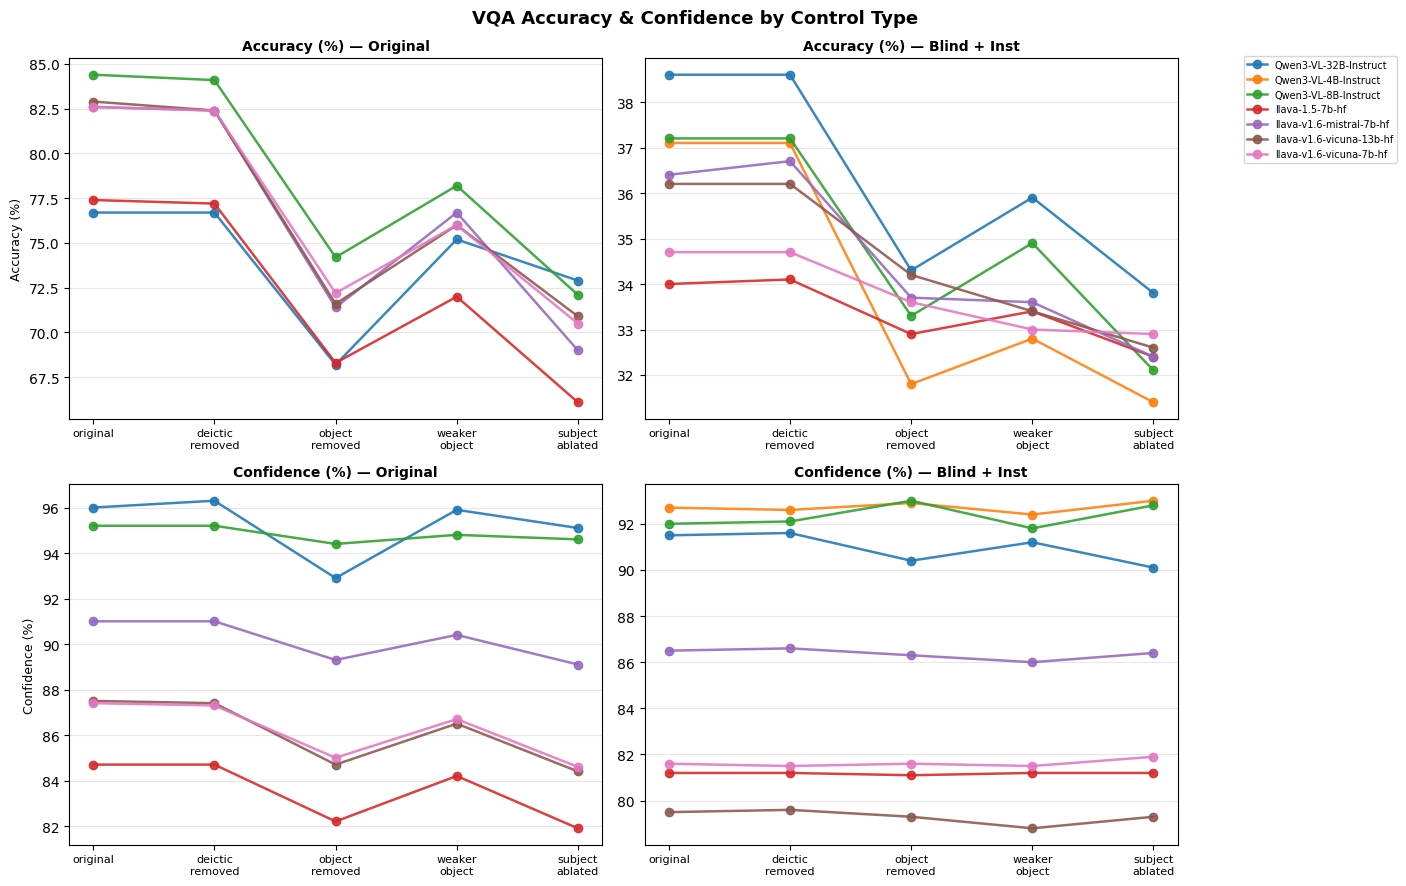

In [27]:
import matplotlib.pyplot as plt

datasets = ['vqa_1k_control', 'vqa_1k_control_inst_blind']
ds_labels = {'vqa_1k_control': 'Original', 'vqa_1k_control_inst_blind': 'Blind + Inst'}
ct_labels = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'subject\nablated']
models_list = sorted(summary['model'].unique())
model_colors = {m: plt.cm.tab10(i) for i, m in enumerate(models_list)}
x = range(len(control_type_order))

fig, axes = plt.subplots(2, 2, figsize=(14, 9)) # , sharey='row')

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for model in models_list:
            sub = summary[(summary['model'] == model) & (summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            ax.plot(x, sub[metric].values,
                    color=model_colors[model], marker='o', linewidth=1.8,
                    label=model, alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


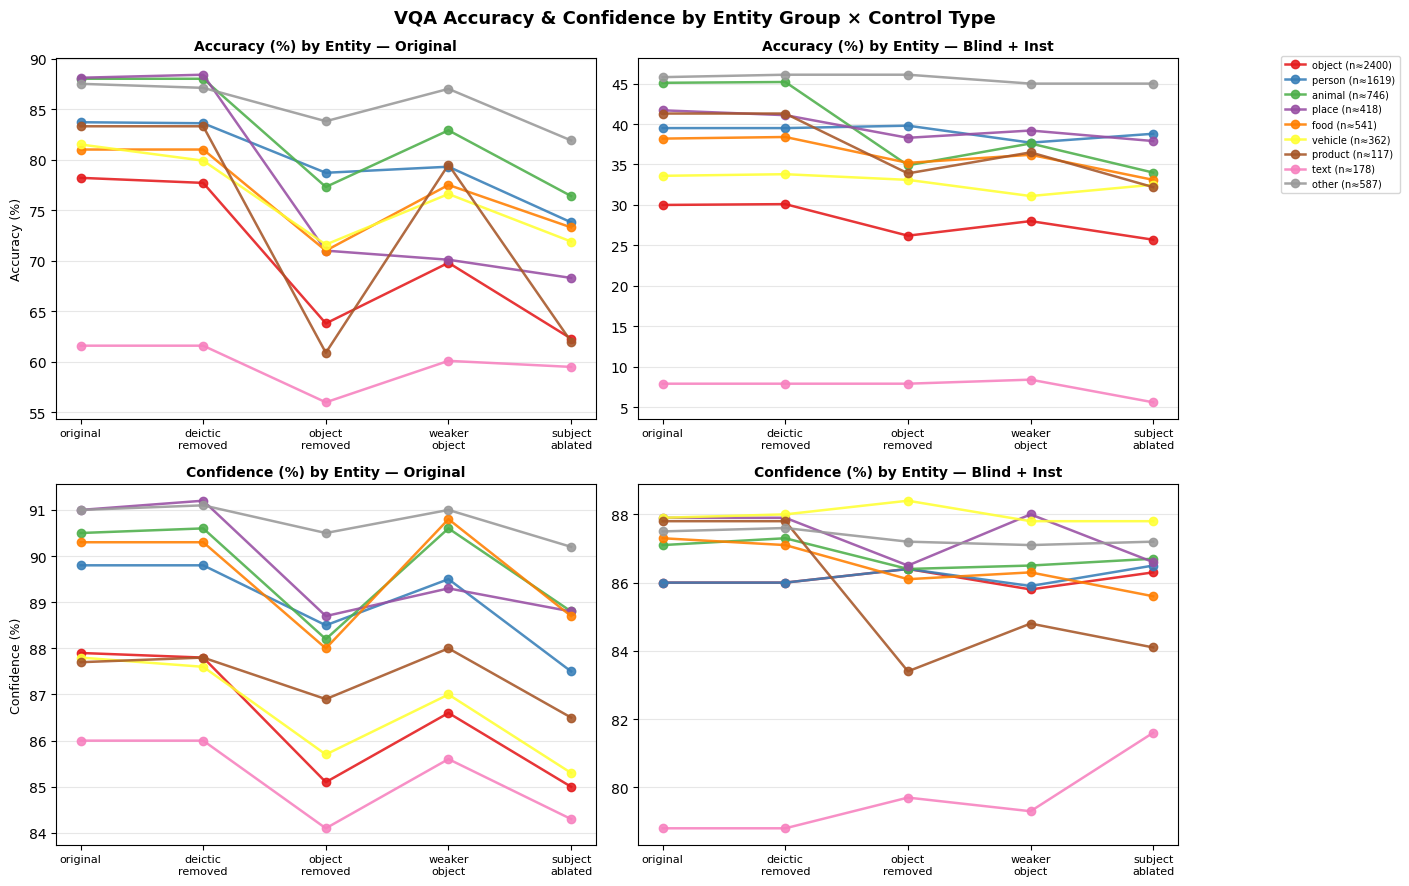

In [28]:
# Entity group analysis: accuracy and confidence across control types
ENT_ORDER = ['object', 'person', 'animal', 'place', 'food', 'vehicle', 'product', 'text', 'other']

ent_summary = (
    df[df['ent'].notna()]
    .groupby(['ent', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
ent_summary['accuracy'] = (ent_summary['accuracy'] * 100).round(1)
ent_summary['confidence'] = (ent_summary['confidence'] * 100).round(1)
ent_summary['control_type'] = pd.Categorical(
    ent_summary['control_type'], categories=control_type_order, ordered=True
)

ent_colors = {e: plt.cm.Set1(i / len(ENT_ORDER)) for i, e in enumerate(ENT_ORDER)}

fig, axes = plt.subplots(2, 2, figsize=(14, 9)) # , sharey='row')

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for ent in ENT_ORDER:
            sub = ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            n_mean = int(ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]['n'].mean())
            ax.plot(x, sub[metric].values,
                    color=ent_colors[ent], marker='o', linewidth=1.8,
                    label=f'{ent} (n≈{n_mean})', alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} by Entity — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Entity Group × Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
